# Post Lab Task - Week 6

## Perform PCA and Clustering Task on Titanic Dataset

### Task 1: Data Acquisition and Feature Selection

**Concept:** Load the Titanic dataset and select suitable numerical and categorical features required for PCA and clustering analysis.

In [1]:
import warnings

In [2]:
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd
import numpy as np

In [4]:
titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

In [5]:
titanic_df = pd.read_csv(titanic_url)

In [6]:
features = [
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'Embarked'
]

In [7]:
X_titanic = titanic_df[features].copy()

In [8]:
print("Titanic Dataset Shape:", titanic_df.shape)
print("\nSelected Features:")
print(features)
print("\nFirst 5 rows:")
print(X_titanic.head())

Titanic Dataset Shape: (891, 12)

Selected Features:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

First 5 rows:
   Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0       3    male  22.0      1      0   7.2500        S
1       1  female  38.0      1      0  71.2833        C
2       3  female  26.0      0      0   7.9250        S
3       1  female  35.0      1      0  53.1000        S
4       3    male  35.0      0      0   8.0500        S


### Task 2: Data Preprocessing

**Concept:** Handle missing values in the Titanic dataset and convert categorical attributes into numerical form so that the data can be used for PCA and K-Means clustering.

In [10]:
X_titanic['Age'] = X_titanic['Age'].fillna(
    X_titanic['Age'].median()
)

In [11]:
X_titanic['Embarked'] = X_titanic['Embarked'].fillna(
    X_titanic['Embarked'].mode()[0]
)

In [12]:
X_titanic = pd.get_dummies(
    X_titanic,
    columns=['Sex', 'Embarked'],
    drop_first=True
)

In [13]:
print("Missing Values After Preprocessing:")
print(X_titanic.isnull().sum())
print("\nPreprocessed Dataset Shape:", X_titanic.shape)
print("\nFirst 5 rows:")
print(X_titanic.head())

Missing Values After Preprocessing:
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64

Preprocessed Dataset Shape: (891, 8)

First 5 rows:
   Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  Embarked_S
0       3  22.0      1      0   7.2500      True       False        True
1       1  38.0      1      0  71.2833     False       False       False
2       3  26.0      0      0   7.9250     False       False        True
3       1  35.0      1      0  53.1000     False       False        True
4       3  35.0      0      0   8.0500      True       False        True


### Task 3: Feature Standardization

**Concept:** Standardize the preprocessed Titanic features so that all attributes have a comparable scale before applying PCA and K-Means clustering.

In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
scaler = StandardScaler()

In [16]:
X_scaled = scaler.fit_transform(X_titanic)

In [18]:
print("Feature standardization completed successfully.")
print("Standardized Dataset Shape:", X_scaled.shape)

Feature standardization completed successfully.
Standardized Dataset Shape: (891, 8)


### Task 4: Applying Principal Component Analysis (PCA)

**Concept:** Apply PCA to transform the standardized Titanic features into a two-dimensional feature space while retaining the major variations present in the dataset.

In [19]:
from sklearn.decomposition import PCA

In [20]:
pca = PCA(n_components=2)

In [21]:
X_pca = pca.fit_transform(X_scaled)

In [22]:
pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

In [23]:
print("PCA transformation completed successfully.")
print("PCA Dataset Shape:", X_pca.shape)

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print(
    "\nTotal Explained Variance:",
    pca.explained_variance_ratio_.sum()
)

PCA transformation completed successfully.
PCA Dataset Shape: (891, 2)

Explained Variance Ratio:
[0.2300211  0.21295421]

Total Explained Variance: 0.44297531136994317


### Task 5: Visualizing the PCA-Reduced Feature Space

**Concept:** Plot the first two principal components to visualize the distribution of Titanic passengers in the PCA-reduced feature space.

In [24]:
import matplotlib.pyplot as plt

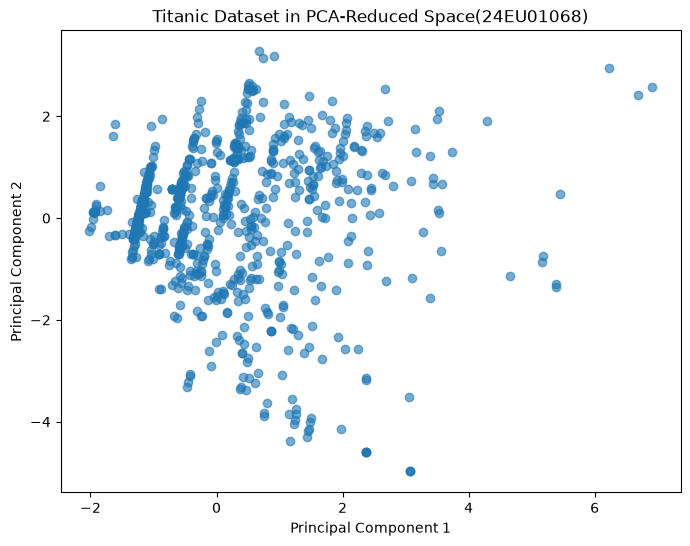

In [25]:
plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Titanic Dataset in PCA-Reduced Space(24EU01068)")

plt.show()

### Task 6: Determining the Optimal Number of Clusters Using Elbow Method

**Concept:** Apply K-Means clustering for different values of K and calculate the Within-Cluster Sum of Squares (WCSS) to identify an appropriate number of clusters.

In [26]:
from sklearn.cluster import KMeans

In [27]:
import matplotlib.pyplot as plt

In [28]:
wcss = []

In [29]:
for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_pca)

    wcss.append(kmeans.inertia_)


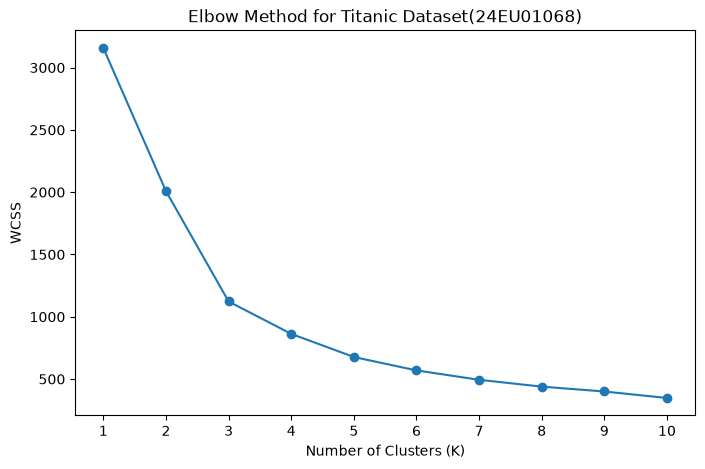

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Titanic Dataset(24EU01068)")

plt.xticks(range(1, 11))
plt.show()

### Task 7: Applying K-Means Clustering

**Concept:** Apply K-Means clustering on the two-dimensional PCA feature space to group Titanic passengers based on similarities in their transformed features.

In [31]:
from sklearn.cluster import KMeans

In [32]:
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42,
    n_init=10
)

In [33]:
cluster_labels = kmeans.fit_predict(X_pca)

In [37]:
pca_df['Cluster'] = cluster_labels

In [38]:
print("K-Means clustering completed successfully.")
print("\nCluster Distribution:")
print(pca_df['Cluster'].value_counts().sort_index())

K-Means clustering completed successfully.

Cluster Distribution:
Cluster
0    229
1    525
2    137
Name: count, dtype: int64


### Task 8: Evaluating Clustering Performance

**Concept:** Evaluate the quality of the generated clusters using the Silhouette Score and Calinski-Harabasz Score.

In [39]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

In [40]:
sil_score = silhouette_score(
    X_pca,
    cluster_labels
)

In [41]:
ch_score = calinski_harabasz_score(
    X_pca,
    cluster_labels
)

In [42]:
print("--- Clustering Performance ---")
print(f"Silhouette Score: {sil_score:.4f}")
print(f"Calinski-Harabasz Score: {ch_score:.2f}")

--- Clustering Performance ---
Silhouette Score: 0.5098
Calinski-Harabasz Score: 804.98


### Task 9: Visualizing K-Means Clusters in PCA Space

**Concept:** Visualize the clusters generated by K-Means in the two-dimensional PCA feature space along with their corresponding cluster centroids.

In [43]:
import matplotlib.pyplot as plt

In [44]:
centroids = kmeans.cluster_centers_

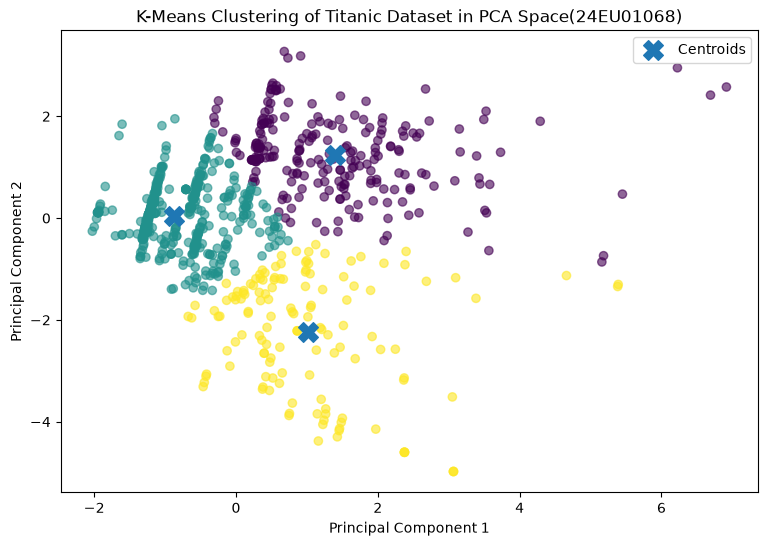

In [45]:
plt.figure(figsize=(9, 6))

# Plot clustered data
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    alpha=0.6
)

# Plot cluster centroids
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='X',
    s=200,
    label='Centroids'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering of Titanic Dataset in PCA Space(24EU01068)")

plt.legend()
plt.show()

### Task 10: Comparing Clusters with Passenger Survival

**Concept:** Compare the generated K-Means clusters with the actual passenger survival information to understand how survival patterns are distributed across the identified clusters.

In [46]:
pca_df['Survived'] = titanic_df['Survived'].values

In [47]:
cluster_survival = pd.crosstab(
    pca_df['Cluster'],
    pca_df['Survived']
)

In [48]:
cluster_survival.columns = [
    'Not Survived',
    'Survived'
]

In [49]:
print("--- Cluster vs Survival Comparison ---")
print(cluster_survival)

--- Cluster vs Survival Comparison ---
         Not Survived  Survived
Cluster                        
0                  85       144
1                 396       129
2                  68        69


### Task 11: Visualizing Clusters and Actual Survival Labels

**Concept:** Compare K-Means cluster assignments with actual Titanic survival labels in the PCA-reduced space to visually analyze the relationship between the unsupervised clusters and passenger survival.

In [50]:
import matplotlib.pyplot as plt

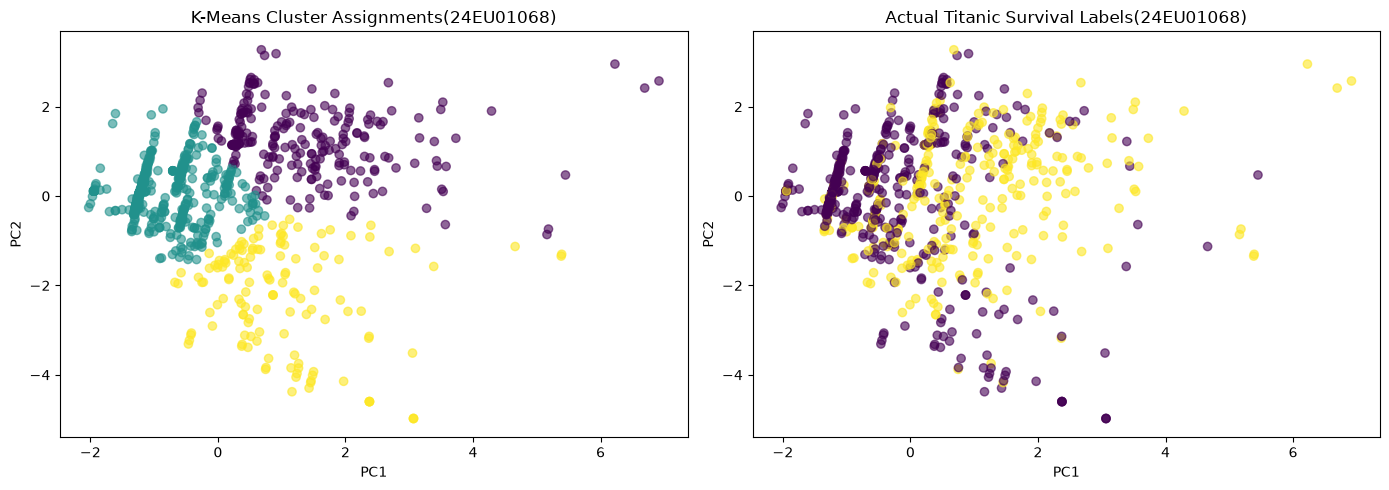

In [52]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

axes[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    alpha=0.6
)

axes[0].set_title("K-Means Cluster Assignments(24EU01068)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=titanic_df['Survived'],
    alpha=0.6
)

axes[1].set_title("Actual Titanic Survival Labels(24EU01068)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()